# Demonstration of fmLCA

> Brightcon 2026 demo notebook.

Development site: [fmLCA on GitHub](https://github.com/see-lab/fmLCA)
fmLCA Version: 0.0.1

In [50]:
# Import packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fmLCA imports
from fmlca import csv_to_json_translator, create_fmu, lca_engine
from fmlca.run_fmu import inspect_fmu, simulate_system_fmu, sequential_cosim

# Use a colorblind-focused plotting palette for all examples
plt.style.use("tableau-colorblind10")

In [51]:
# Resolve project root and file paths
# Verify project root and FMU directory exists
cwd = Path.cwd().resolve()
if (cwd / "fmu").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "fmu").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not locate project root containing the fmu/ folder")

# Set FMU file paths
FMU_DIR = PROJECT_ROOT / "fmu"
PV_WECC_FMU = FMU_DIR / "PV_System_WECC.fmu"
PV_MRO_FMU = FMU_DIR / "PV_System_MRO.fmu"
LCA_WECC_FMU = FMU_DIR / "PvWecc_Ipcc_v1.0.fmu"
LCA_MRO_FMU = FMU_DIR / "PvMro_Ipcc_v1.1.fmu"

# Define time constants
SECONDS_PER_DAY = 24 * 3600
SECONDS_PER_YEAR = 365 * SECONDS_PER_DAY

# Print directories
print(f"Project root: {PROJECT_ROOT}")
print(f"FMU directory: {FMU_DIR}")

Project root: C:\Users\khinkelm\git\Brightcon2026
FMU directory: C:\Users\khinkelm\git\Brightcon2026\fmu


## Example 1: One FMU

Goal: Simulate one system FMU for 24 hours and plot power signals (W).
- Grid: `PGriRea.y`
- PV: `pv.P`
- Load: `loa.P`

In [52]:
# View some fmu details
inspect_fmu(PV_WECC_FMU, max_vars=12)


=== PV_System_WECC.fmu ===
Model name: PV_System_WECC
FMI version: 2.0
Co-Simulation: True
I/O/parameter variables shown: 12 of 69
  - parameter n
  - parameter i
  - parameter priGriBuy
  - parameter priGriSel
  - parameter ratCO2
  - parameter n_pv
  - parameter PV_surface
  - parameter etaPV
  - parameter W_m2_nominal
  - parameter n_bess
  - parameter etaBatDis
  - parameter etaBatChr


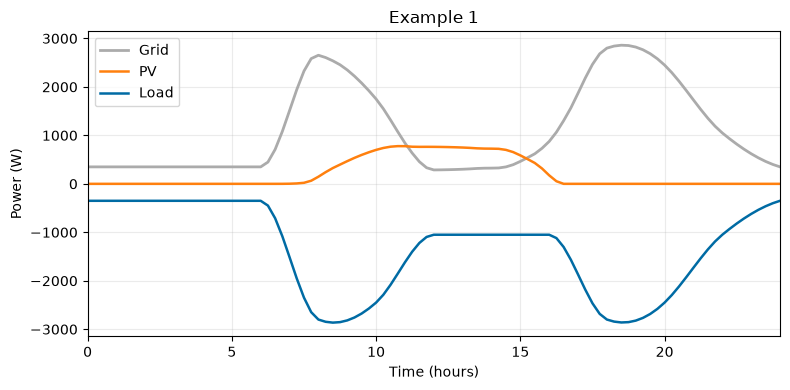

Example 1 summary
Samples: 97
Final PGriRea.y: 350.000 W
Final pv.P:      0.000 W
Final loa.P:     -350.000 W


In [53]:
# Simulate the model 
res1 = simulate_system_fmu(
    fmu_path=PV_WECC_FMU,
    start_s=0.0,
    stop_s=SECONDS_PER_DAY,
    outputs=["PGriRea.y", "pv.P", "loa.P"],
    output_interval_s=900.0,
    start_values={"n_pv": 1.0},
)

# Convert time to hours for plotting
time_h = np.array(res1["time"], dtype=np.float64) / 3600.0

# Plot
plt.figure(figsize=(8, 4))
plt.plot(time_h, res1["PGriRea.y"], color="C2", label="Grid", linewidth=2.0)
plt.plot(time_h, res1["pv.P"], color="C1", label="PV", linewidth=1.8)
plt.plot(time_h, res1["loa.P"], color="C0", label="Load", linewidth=1.8)
plt.xlabel("Time (hours)")
plt.ylabel("Power (W)")
plt.title("Example 1")
plt.xlim(0, 24)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Summarize the results
print("Example 1 summary")
print(f"Samples: {len(res1)}")
print(f"Final PGriRea.y: {float(res1['PGriRea.y'][-1]):.3f} W")
print(f"Final pv.P:      {float(res1['pv.P'][-1]):.3f} W")
print(f"Final loa.P:     {float(res1['loa.P'][-1]):.3f} W")

## Example 2: Coupled System + LCA FMUs

Goal: Co-simulate one year with system output `gri.P.real` driving LCA input `u`.
Plot: cumulative GWP with daily grid power range.

In [54]:
# See the LCA FMU details
# This FMU can be generated via the fmlca.create_fmu API
inspect_fmu(LCA_WECC_FMU, max_vars=10)


=== PvWecc_Ipcc_v1.0.fmu ===
Model name: PvweccIpccV10
FMI version: 2.0
Co-Simulation: True
I/O/parameter variables shown: 3 of 3
  - parameter n_pv
  - input     u
  - output    y


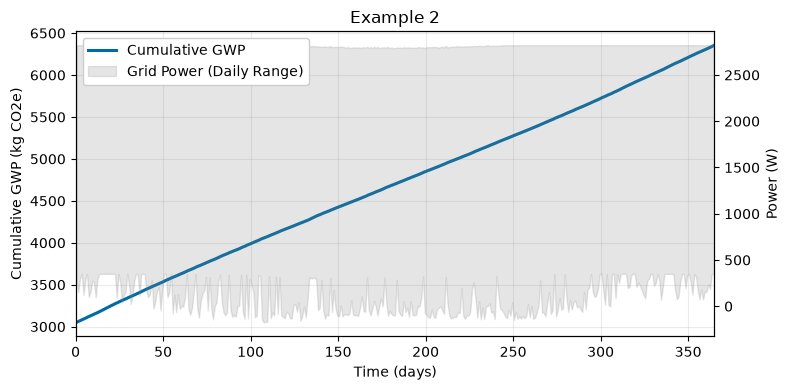

Example 2 summary
Samples (LCA): 8761
Final cumulative GWP: 6356 kg CO2e
Integrated power input: 9.545 MWh


In [55]:
# Co-simulate the two FMUs for one year
sys2, lca2 = sequential_cosim(
    system_fmu=PV_WECC_FMU,
    lca_fmu=LCA_WECC_FMU,
    start_s=0.0,
    stop_s=SECONDS_PER_YEAR,
    system_output="gri.P.real",
    n_pv=1.0,
    output_interval_s=3600.0,
 )

# Extract series
time_days = np.array(lca2["time"], dtype=np.float64) / SECONDS_PER_DAY
gwp = np.array(lca2["y"], dtype=np.float64)
energy_mwh = float(np.trapezoid(np.array(lca2["u"], dtype=np.float64), np.array(lca2["time"], dtype=np.float64)) / 3.6e9)

# Daily envelope for grid P real
g = pd.DataFrame({
    "day": (np.array(sys2["time"], dtype=np.float64) // SECONDS_PER_DAY).astype(int),
    "p": np.array(sys2["gri.P.real"], dtype=np.float64),
}).groupby("day")["p"].agg(["min", "max"])
x_day = g.index.to_numpy(dtype=np.float64) + 0.5

# Plot cumulative GWP (left) + daily grid envelope (right)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(time_days, gwp, color="C0", linewidth=2.2, label="Cumulative GWP")
ax1.set(xlabel="Time (days)", ylabel="Cumulative GWP (kg CO2e)", title="Example 2", xlim=(0, 365))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.fill_between(x_day, g["min"], g["max"], color="gray", alpha=0.2, label="Grid Power (Daily Range)")
ax2.set_ylabel("Power (W)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax2.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=1.0, facecolor="white")
leg.set_zorder(1000)

plt.tight_layout()
plt.show()

# Results summary
print("Example 2 summary")
print(f"Samples (LCA): {len(lca2)}")
print(f"Final cumulative GWP: {gwp[-1]:.0f} kg CO2e")
print(f"Integrated power input: {energy_mwh:.3f} MWh")

## Example 3: Scenario Sweep

Goal: Compare WECC and MRO scenarios across `n_pv` values.
Output: final cumulative GWP versus number of PV panels.

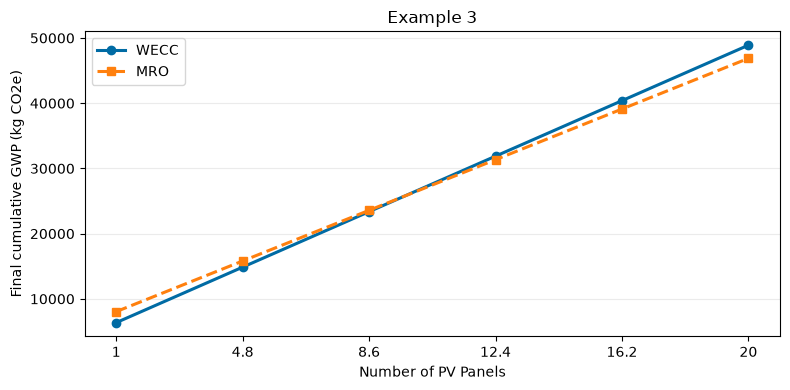

In [56]:
systems = [
    ("WECC", PV_WECC_FMU, LCA_WECC_FMU),
    ("MRO", PV_MRO_FMU, LCA_MRO_FMU),
]

n_pv_values = np.linspace(1.0, 20.0, 6)

rows = []
for grid_name, system_fmu, lca_fmu in systems:
    for n_pv in n_pv_values:
        _, lca_res = sequential_cosim(
            system_fmu=system_fmu,
            lca_fmu=lca_fmu,
            start_s=0.0,
            stop_s=SECONDS_PER_YEAR,
            system_output="gri.P.real",
            n_pv=n_pv,
            output_interval_s=3600.0,
        )

        t = np.array(lca_res["time"], dtype=np.float64)
        u = np.array(lca_res["u"], dtype=np.float64)
        y = np.array(lca_res["y"], dtype=np.float64)
        rows.append({
            "grid": grid_name,
            "n_pv": n_pv,
            "final_cumulative_gwp_kgco2e": float(y[-1]),
            "energy_mwh": float(np.trapezoid(u, t) / 3.6e9),
        })

# Save sorted results to dataframe
df3 = pd.DataFrame(rows).sort_values(["grid", "n_pv"]).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
style_map = {
    "WECC": {"color": "C0", "linestyle": "-", "marker": "o"},
    "MRO":  {"color": "C1", "linestyle": "--", "marker": "s"},
}
# Plot final cumulative GWP vs n_pv for each grid scenario
for grid_name in ["WECC", "MRO"]:
    subset = df3[df3["grid"] == grid_name].sort_values("n_pv")
    style = style_map[grid_name]
    ax.plot(
        subset["n_pv"],
        subset["final_cumulative_gwp_kgco2e"],
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markersize=6,
        linewidth=2.2,
        label=grid_name,
    )
# Plot settings
ax.set_xlabel("Number of PV Panels")
ax.set_ylabel("Final cumulative GWP (kg CO2e)")
ax.set_xticks(n_pv_values)
ax.set_xticklabels([f"{v:g}" for v in n_pv_values])
ax.set_title("Example 3")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Bonus: fmLCA Python API

Streamlined workflow from inventory input to LCA result and FMU generation.

In [57]:
# Get package
import json

# Define paths
CSV_PATH = PROJECT_ROOT / "data" / "example.csv"
JSON_PATH = PROJECT_ROOT / "data" / "example.json"
METHOD_IPCC_PATH = PROJECT_ROOT / "data" / "ipcc.json"
METHOD_RECIPE_PATH = PROJECT_ROOT / "data" / "recipe.json"
METHOD_IPCC = [m["name"] for m in json.loads(METHOD_IPCC_PATH.read_text(encoding="utf-8"))["lcia_methods"]]
METHOD_RECIPE = [m["name"] for m in json.loads(METHOD_RECIPE_PATH.read_text(encoding="utf-8"))["lcia_methods"]]

# Show paths and methods
print(f"CSV input: {CSV_PATH}")
print(f"JSON output: {JSON_PATH}")
print(f"Methods file: {METHOD_IPCC_PATH}")
print(f"Loaded method: {METHOD_IPCC}")
print(f"Methods file: {METHOD_RECIPE_PATH}")
print(f"Loaded method: {METHOD_RECIPE}")

CSV input: C:\Users\khinkelm\git\Brightcon2026\data\example.csv
JSON output: C:\Users\khinkelm\git\Brightcon2026\data\example.json
Methods file: C:\Users\khinkelm\git\Brightcon2026\data\ipcc.json
Loaded method: ['IPCC 2021 climate change total excl biogenic GWP100']
Methods file: C:\Users\khinkelm\git\Brightcon2026\data\recipe.json
Loaded method: ['ReCiPe 2016 endpoint (H) total human health', 'ReCiPe 2016 endpoint (H) total ecosystem quality', 'ReCiPe 2016 endpoint (H) total natural resources']


In [58]:
# Convert inventory CSV to JSON 
csv_to_json_translator(str(CSV_PATH), str(JSON_PATH))
print(f"Converted inventory to: {JSON_PATH}")

Converting CSV to LCI JSON using flexible configuration...
   Input: C:\Users\khinkelm\git\Brightcon2026\data\example.csv
   Output: C:\Users\khinkelm\git\Brightcon2026\data\example.json
🔄 Importing LCI data...
   📁 File: C:\Users\khinkelm\git\Brightcon2026\data\example.csv
   📋 Format: csv
   📊 Found 3 rows with 11 columns
   🔗 Field mapping: {'name': 'Item', 'amount': 'Amount', 'unit': 'Unit', 'stage': 'Stage', 'location': 'Location', 'database': 'Database', 'code': 'UUID', 'process_match': None, 'brightway_code': 'Brightway Match Code', 'brightway_database': None, 'brightway_location': None, 'brightway_ref_product': None}
   📊 Parameters detected: ['n_units']
   ⚡ Energy process: Electricity → using energy_metadata reference
   ✅ Processed 3 valid exchanges
   📊 Lifecycle stages: ['Production', 'Use']
   ⚡ Energy processes: 1
   ⚡ Energy metadata retained from inventory base: 25.0 kWh
Successfully converted CSV data
   Process: Example Production System
   Exchanges: 4
   Parameters

In [59]:
# Run LCA directly. This runs the LCA and outputs the results without creating an FMU. 

# Set the Brightway project for the LCA calculation 
# Note! We are skiping over the step where you set up a BW project here. 
# Make sure you have already set up the Brightway project and imported the necessary databases.
# Then, replace "LCA-FMU" with the name of your Brightway project if it is different.
import os
os.environ["FMLCA_BW_PROJECT"] = "LCA-FMU"


# Run the LCA with the specified project and two methods
print("Running LCA with IPCC method...")
example_results_ipcc = lca_engine(str(JSON_PATH), METHOD_IPCC)
print("\nRunning LCA with ReCiPe method...")
example_results_recipe = lca_engine(str(JSON_PATH), METHOD_RECIPE)
print("Complete!")


Running LCA with IPCC method...


TypeError: 'module' object is not callable

Saved CSV: C:\Users\khinkelm\git\Brightcon2026\results\example_lca_stage_breakdown_ipcc.csv
Saved CSV: C:\Users\khinkelm\git\Brightcon2026\results\example_lca_stage_breakdown_recipe.csv


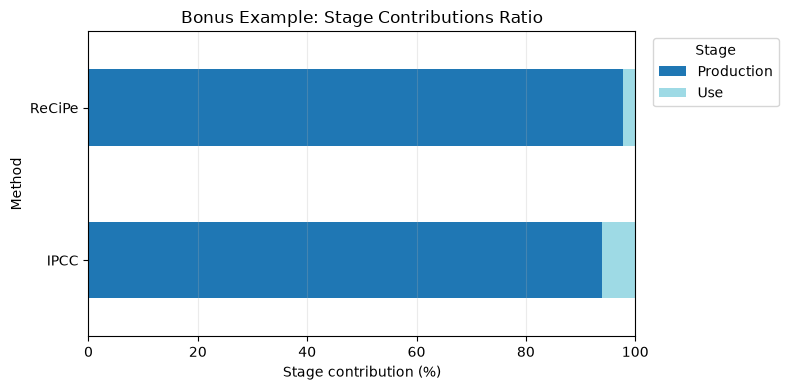

In [ ]:
# Save stage-level CSVs, then compare IPCC vs ReCiPe with a normalized 100% stacked bar chart
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

# Function to save df with stage level breakdown results
def stage_breakdown_df(result_dict, method_label):
    return pd.DataFrame(
        [
            {
                "method": method_label,
                "method_key": method_key,
                "method_name": result_dict["impact_results"][method_key]["method_name"],
                "stage": stage_name,
                "unit": stage_values["unit"],
                "stage_score": float(stage_values["score"]),
            }
            for method_key, stages in result_dict["stage_breakdown"].items()
            for stage_name, stage_values in stages.items()
        ]
    ).sort_values(["method", "method_name", "stage"]).reset_index(drop=True)

# Get stage results
ipcc_stage_df = stage_breakdown_df(example_results_ipcc, "IPCC")
recipe_stage_df = stage_breakdown_df(example_results_recipe, "ReCiPe")

# Save results to csv files
ipcc_csv = results_dir / "example_lca_stage_breakdown_ipcc.csv"
recipe_csv = results_dir / "example_lca_stage_breakdown_recipe.csv"
ipcc_stage_df.to_csv(ipcc_csv, index=False)
recipe_stage_df.to_csv(recipe_csv, index=False)
print(f"Saved CSV: {ipcc_csv}")
print(f"Saved CSV: {recipe_csv}")

# Combine stage results for plotting
stage_df = pd.concat([ipcc_stage_df, recipe_stage_df], ignore_index=True)
stage_share = stage_df.pivot_table(
    index="method",
    columns="stage",
    values="stage_score",
    aggfunc="sum",
    fill_value=0.0,
)
stage_share = stage_share.div(stage_share.sum(axis=1), axis=0) * 100.0

# Plot -- not particularly useful, but a visual for demo purposes
ax = stage_share.plot(kind="barh", stacked=True, figsize=(8, 4), colormap="tab20")
ax.set_xlabel("Stage contribution (%)")
ax.set_ylabel("Method")
ax.set_title("Bonus Example: Stage Contributions Ratio")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", alpha=0.25)
ax.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# Create an LCA FMU -- default blackbox settings
# This process first runs the LCA(s) -- n+1 runs for n parameters -- then creates the FMU.
fmu_path = create_fmu(str(JSON_PATH), str(FMU_DIR), method="ipcc", version="0.0.1")
print(f"Created FMU: {fmu_path}")

Creating FMU: Example_Ipcc_v0.0.1
LCI file: C:\Users\khinkelm\git\Brightcon2026\data\example.json
Method: ipcc
🔍 LCI file requires database: ecoinvent-3.12-cutoff
✅ Current project 'LCA-FMU' already has ecoinvent-3.12-cutoff
🔍 Scanning 2 databases...
   ✅ ecoinvent-3.12-biosphere: ecoinvent v3.12
   ✅ ecoinvent-3.12-cutoff: ecoinvent v3.12
🔄 Loading LCI data from C:\Users\khinkelm\git\Brightcon2026\data\example.json
🔄 Importing LCI data...
   📁 File: C:\Users\khinkelm\git\Brightcon2026\data\example.json
   📋 Format: json
✅ LCI data loaded: Example Production System
✅ Using primary database: ecoinvent-3.12-cutoff
   ✅ Added: Steel (100.000 kg)
   ✅ Added: Transport (50.000 pkm)
   ✅ Energy unit verification: metadata unit KWH matches assigned inventory unit KWH for 'market for electricity, high voltage'.


100%|██████████| 1/1 [00:00<?, ?it/s]


22:52:07-0400 [info     ] Vacuuming database            
⚠️ Disk-space issue detected during temporary DB write
   Retrying once with VACUUM temporarily disabled...


100%|██████████| 1/1 [00:00<?, ?it/s]


✅ Temporary DB write succeeded with low-disk fallback
✅ Created temporary database: LCA_Temp_DB_Example_Production_System_0de14554
✅ Main process ready: Example Production System

=== LCIA Calculations ===
   ✅ Resolved: IPCC climate change

🔄 Calculating: IPCC climate change
  ✅ Total impact: 2.177235e+02 kg CO2-eq
🧹 Cleaned up temporary database: LCA_Temp_DB_Example_Production_System_0de14554

✅ LCA calculation complete!
  ✅ Extracted: total = 2.1772e+02 kg CO2-eq, use = 1.4558e+01 kg CO2-eq, factor/MJ = 4.0438e+00
  ✅ Stage impacts extracted:
     Production  : 2.0317e+02 kg CO2-eq
     Use         : 1.4558e+01 kg CO2-eq
🔍 LCI file requires database: ecoinvent-3.12-cutoff
✅ Current project 'LCA-FMU' already has ecoinvent-3.12-cutoff
🔍 Scanning 2 databases...
   ✅ ecoinvent-3.12-biosphere: ecoinvent v3.12
   ✅ ecoinvent-3.12-cutoff: ecoinvent v3.12
🔄 Loading LCI data from C:\Users\khinkelm\AppData\Local\Temp\8\tmpvge6gl0u.json
🔄 Importing LCI data...
   📁 File: C:\Users\khinkelm\AppD

100%|██████████| 1/1 [00:00<?, ?it/s]


22:53:01-0400 [info     ] Vacuuming database            
⚠️ Disk-space issue detected during temporary DB write
   Retrying once with VACUUM temporarily disabled...


100%|██████████| 1/1 [00:00<?, ?it/s]


✅ Temporary DB write succeeded with low-disk fallback
✅ Created temporary database: LCA_Temp_DB_Example_Production_System_35be5a4b
✅ Main process ready: Example Production System

=== LCIA Calculations ===
   ✅ Resolved: IPCC climate change

🔄 Calculating: IPCC climate change
  ✅ Total impact: 3.265852e+02 kg CO2-eq
🧹 Cleaned up temporary database: LCA_Temp_DB_Example_Production_System_35be5a4b

✅ LCA calculation complete!
  ✅ Extracted: total = 3.2659e+02 kg CO2-eq, use = 2.1837e+01 kg CO2-eq, factor/MJ = 6.0657e+00
  ✅ Stage impacts extracted:
     Production  : 3.0475e+02 kg CO2-eq
     Use         : 2.1837e+01 kg CO2-eq

  Building FMU with pythonfmu...
  ✅ FMU built → C:\Users\khinkelm\git\Brightcon2026\fmu\Example_Ipcc_v0.0.1_Simulatable.fmu

  Fixing FMU metadata...
  ✅ FMU metadata fixed → C:\Users\khinkelm\git\Brightcon2026\fmu\Example_Ipcc_v0.0.1.fmu

  Packaging FMU resources as bytecode...
  ✅ Bytecode packaging complete (13 modules + loader stub)
  ✅ Repackaged FMU → C:\Us

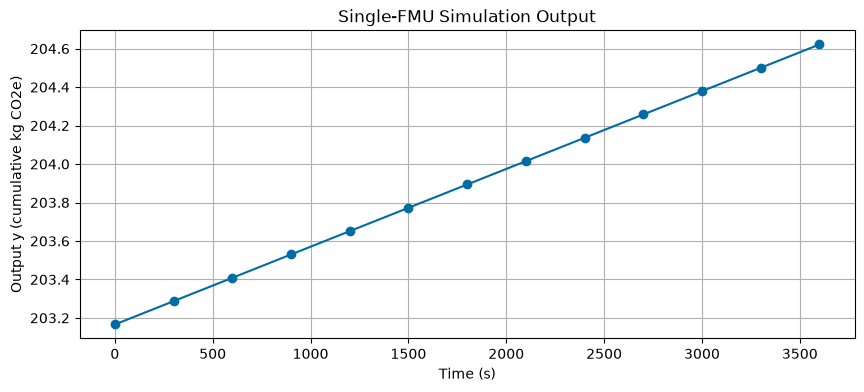

In [ ]:
# Run the created LCA FMU
# Input power: 100 kW, constant rate
# Run the simulation for 1 hour
fmu_simulation = simulate_system_fmu(
    fmu_path=fmu_path,
    start_s=0.0,
    stop_s=3600.0,
    outputs=["y"],
    output_interval_s=300.0,
    start_values={"u": 100.0},
)

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(pd.DataFrame(fmu_simulation)["time"], pd.DataFrame(fmu_simulation)["y"], marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Output y (cumulative kg CO2e)")
plt.title("Single-FMU Simulation Output")
plt.grid(True)
plt.show()

# Thank You

> Demonstration complete.

For follow-up questions, collaboration inquiries, or access details:
- Contact: Kathryn (Katy) Hinkelman
- Research Website: https://theseelab.org
- Organization: University of Vermont

We appreciate your time and interest in fmLCA!